---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 6**

---

**Problem Statement** :

Implement assignment based on logistic regression for binary
classifier and evaluate the performance,

*Case Study* : Predicting Diabetes in Patients: A hospital wants to
predict whether a patient has diabetes or not based on medical
measurements. You are tasked with building a logistic regression
model to assist in early diagnosis using patient data.

---

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Download dataset: - https://www.kaggle.com/datasets/mathchi/diabetes-data-set

df = pd.read_csv("/home/ashx/ML/Projects/fml-lab/data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# initialize data
X = df.iloc[:, :-1].to_numpy()
X.shape

(768, 8)

In [4]:
# initialize targets
y = df.iloc[:,-1].to_numpy()
y.shape

(768,)

In [5]:
# Scale data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# Split data in training and testing sets
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2)

print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (614, 8)
Shape of y_train : (614,)
Shape of X_test : (154, 8)
Shape of y_test : (154,)


In [7]:
# Import model fit to data and make predictions
from sklearn.linear_model import LogisticRegression

regressor = LogisticRegression(random_state=0).fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [8]:
# Print model accuracy
from sklearn.metrics import accuracy_score 

print(f"model accuracy : {accuracy_score(y_test, y_pred)}")

model accuracy : 0.7792207792207793


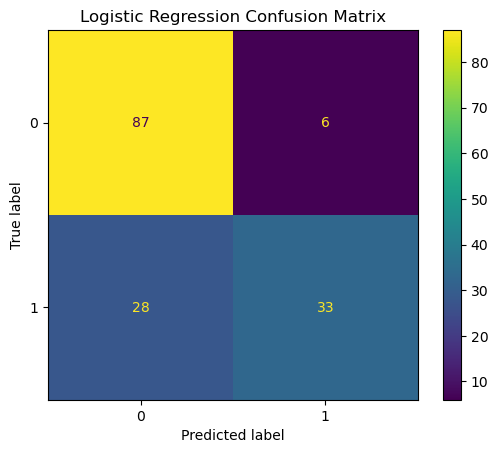

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(X_test, y_test, y_pred, normalize=None):
    
    cm = confusion_matrix(y_test, y_pred, normalize=normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title("Logistic Regression Confusion Matrix")
    plt.show()

plot_confusion_matrix(X_test, y_test, y_pred)

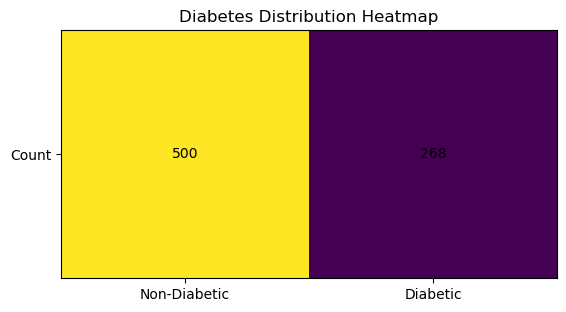

In [10]:
def plot_diabetes_heatmap(y):

    non_diabetic = np.sum(y == 0)
    diabetic = np.sum(y == 1)

    data = np.array([[non_diabetic, diabetic]])

    plt.imshow(data)
    plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
    plt.yticks([0], ["Count"])

    for i in range(2):
        plt.text(i, 0, data[0, i], ha="center", va="center")

    plt.title("Diabetes Distribution Heatmap")
    plt.show()

plot_diabetes_heatmap(y)